In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage
from langchain_core.messages import BaseMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,add_messages
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
#sys.path.insert(2, r'C:\Users\Dharmendra Vartika\LLM\langchain_document_loader')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from typing import TypedDict,Literal,Annotated
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.chat_models import init_chat_model

from langgraph.checkpoint.memory import InMemorySaver

In [2]:
class human_in_loop(TypedDict):
    message :Annotated[list[BaseMessage],add_messages]
    # :str
    feedack :str
    
model=init_chat_model("openai:gpt-4o", temperature=0.7)

In [3]:
def chat(state:human_in_loop):
    question =state['message']
    #print ('message list ',state['message'])
    #print ('message stste ',state)
    result=model.invoke(question,config=config1)
    return({'message':[result]})
def human(state:human_in_loop):
    print ('human in the loop')
def summersie(state:human_in_loop):
    question =state['message']
    #prompt =ChatPromptTemplate.from_template("please summerise message output in 10 words")
    system_message=[SystemMessage(content='please summerise message output in 10 words')]
    mesg=system_message+question
    result=model.invoke(mesg,config=config1)
    return({'message':[result]}) 

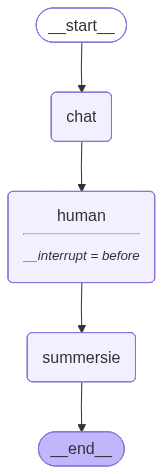

In [4]:
graph=StateGraph(human_in_loop)
graph.add_node('chat',chat)
graph.add_node('human',human)
graph.add_node('summersie',summersie)
graph.add_edge(START,'chat')
graph.add_edge('chat','human')
graph.add_edge('human','summersie')
graph.add_edge('summersie',END)
checkpointer =InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer,interrupt_before=["human"])
workflow


In [5]:
question ='What is cricket in 500 words'
initial_stage={'message':[HumanMessage(content=question)]}
config1 = {"configurable": {"thread_id": "13"}}
#initial_stage={'message':question,'feedack':'Approve'}


In [6]:
res=workflow.invoke(initial_stage,config=config1)

In [7]:
workflow.get_state(config1)

StateSnapshot(values={'message': [HumanMessage(content='What is cricket in 500 words', additional_kwargs={}, response_metadata={}, id='b135d906-160e-48d8-8d44-d46501b1bd35'), AIMessage(content="Cricket is a bat-and-ball sport that emerged in England during the 16th century and has since evolved into a game of international acclaim, widely followed in countries such as India, Australia, England, Pakistan, South Africa, and the West Indies, among others. Known for its rich history and tradition, cricket combines elements of strategy, skill, and endurance, making it a unique and complex sport.\n\nThe sport is played between two teams, each consisting of eleven players. The central objective is to score more runs than the opposing team. A match is divided into innings, where one team bats and attempts to score runs while the other bowls and fields, trying to restrict runs and dismiss the batsmen. Players score runs by hitting the ball and running between two sets of wickets or by hitting t

In [8]:
workflow.update_state(config1, values={"feedack": "all good"},as_node='human')


{'configurable': {'thread_id': '13',
  'checkpoint_ns': '',
  'checkpoint_id': '1f123993-71b3-6101-8002-bdb296c4dcc3'}}

In [9]:
res=workflow.invoke(None,config1)

In [10]:
workflow.get_state(config1).config

{'configurable': {'thread_id': '13',
  'checkpoint_ns': '',
  'checkpoint_id': '1f123993-8a70-6e49-8003-d412d03663d4'}}

In [11]:
res

{'message': [HumanMessage(content='What is cricket in 500 words', additional_kwargs={}, response_metadata={}, id='b135d906-160e-48d8-8d44-d46501b1bd35'),
  AIMessage(content="Cricket is a bat-and-ball sport that emerged in England during the 16th century and has since evolved into a game of international acclaim, widely followed in countries such as India, Australia, England, Pakistan, South Africa, and the West Indies, among others. Known for its rich history and tradition, cricket combines elements of strategy, skill, and endurance, making it a unique and complex sport.\n\nThe sport is played between two teams, each consisting of eleven players. The central objective is to score more runs than the opposing team. A match is divided into innings, where one team bats and attempts to score runs while the other bowls and fields, trying to restrict runs and dismiss the batsmen. Players score runs by hitting the ball and running between two sets of wickets or by hitting the ball to the boun

In [72]:
res
for i in res['message']:
    print (i.pretty_print())

================================ Human Message =================================

What is cricket in 500 words
None
================================== Ai Message ==================================

Cricket is a bat-and-ball sport that originated in England and has become immensely popular worldwide, particularly in countries like India, Australia, England, Pakistan, South Africa, Sri Lanka, New Zealand, and the West Indies. It is a game steeped in tradition, with a rich history dating back to the 16th century. The sport is played between two teams, each consisting of eleven players, on a circular or oval-shaped field. The central area of the field is known as the pitch, which is a rectangular strip of prepared ground where most of the action takes place.

The primary objective in cricket is for one team to score more runs than the other. A match is divided into innings, where one team bats and attempts to score runs, while the other team bowls and fields, trying to dismiss the batters 